# Does Product Review Sentiment Influence Sales Performance in E‑Commerce?


# Project Goals

**The main goals of this project are**:

Understand the relationship between product review sentiment and sales performance. Are products with more positive reviews selling significantly more than those with negative reviews? Quantify the impact of review sentiment on sales. Use statistical tests (hypothesis testing) and regression models to measure the effect. Explore data-driven insights for stakeholders. Visualizations and summaries to help marketing teams or managers understand which types of reviews influence sales.



# Data Source

The dataset used in this project is “Summer Product Ratings & Sales Performance” obtained from Kaggle:

Link: Kaggle: Summer Product Ratings & Sales Performance. https://www.kaggle.com/datasets/thedevastator/summer-product-ratings-and-sales-performance-in

Description: This dataset includes product metadata, customer reviews, product ratings, and sales performance metrics.

Format: CSV files, easily loaded into Python or SQL.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from scipy.stats import ttest_ind
import sqlite3

In [14]:
sns.set(style="whitegrid")


In [27]:
# Loading CSV file 
rating_data = pd.read_csv("summer-products-with-rating-and-performance_2020-08.csv")

rating_data.head()





,index,title,title_orig,price,retail_price,currency_buyer,units_sold,uses_ad_boosts,rating,rating_count,...,merchant_rating_count,merchant_rating,merchant_id,merchant_has_profile_picture,merchant_profile_picture,product_url,product_picture,product_id,theme,crawl_month
0,0,2020 Summer Vintage Flamingo Print Pajamas Se...,2020 Summer Vintage Flamingo Print Pajamas Se...,16.00,14,EUR,100,0,3.76,54,...,568,4.128521,595097d6a26f6e070cb878d1,0,NaN,https://www.wish.com/c/5e9ae51d43d6a96e303acdb0,https://contestimg.wish.com/api/webimage/5e9ae...,5e9ae51d43d6a96e303acdb0,summer,2020-08
1,1,SSHOUSE Summer Casual Sleeveless Soirée Party ...,Women's Casual Summer Sleeveless Sexy Mini Dress,8.00,22,EUR,20000,1,3.45,6135,...,17752,3.899673,56458aa03a698c35c9050988,0,NaN,https://www.wish.com/c/58940d436a0d3d5da4e95a38,https://contestimg.wish.com/api/webimage/58940...,58940d436a0d3d5da4e95a38,summer,2020-08
2,2,2020 Nouvelle Arrivée Femmes Printemps et Été ...,2020 New Arrival Women Spring and Summer Beach...,8.00,43,EUR,100,0,3.57,14,...,295,3.989831,5d464a1ffdf7bc44ee933c65,0,NaN,https://www.wish.com/c/5ea10e2c617580260d55310a,https://contestimg.wish.com/api/webimage/5ea10...,5ea10e2c617580260d55310a,summer,2020-08
3,3,Hot Summer Cool T-shirt pour les femmes Mode T...,Hot Summer Cool T Shirt for Women Fashion Tops...,8.00,8,EUR,5000,1,4.03,579,...,23832,4.020435,58cfdefdacb37b556efdff7c,0,NaN,https://www.wish.com/c/5cedf17ad1d44c52c59e4aca,https://contestimg.wish.com/api/webimage/5cedf...,5cedf17ad1d44c52c59e4aca,summer,2020-08
4,4,Femmes Shorts d'été à lacets taille élastique ...,Women Summer Shorts Lace Up Elastic Waistband ...,2.72,3,EUR,100,1,3.10,20,...,14482,4.001588,5ab3b592c3911a095ad5dadb,0,NaN,https://www.wish.com/c/5ebf5819ebac372b070b0e70,https://contestimg.wish.com/api/webimage/5ebf5...,5ebf5819ebac372b070b0e70,summer,2020-08


# Exploring Data

In [29]:
# Checking shape
print("Shape:", rating_data.shape)

# Checking data types
print(rating_data.dtypes)

# Summary statistics
print(rating_data.describe())

# Checking missing values
print(rating_data.isnull().sum())



Shape: (1573, 44)
index                             int64
title                            object
title_orig                       object
price                           float64
retail_price                      int64
currency_buyer                   object
units_sold                        int64
uses_ad_boosts                    int64
rating                          float64
rating_count                      int64
rating_five_count               float64
rating_four_count               float64
rating_three_count              float64
rating_two_count                float64
rating_one_count                float64
badges_count                      int64
badge_local_product               int64
badge_product_quality             int64
badge_fast_shipping               int64
tags                             object
product_color                    object
product_variation_size_id        object
product_variation_inventory       int64
shipping_option_name             object
shipping_option_price 

# Data Cleaning & Wrangling


In [43]:
# Droping rows with missing Sales or Rating
rating_data_clean = rating_data.dropna(subset=['rating', 'units_sold'])


In [44]:
# Converting Sales and Rating to numeric 
rating_data_clean['units_sold'] = pd.to_numeric(rating_data_clean['units_sold'], errors='coerce')
rating_data_clean['rating'] = pd.to_numeric(rating_data_clean['rating'], errors='coerce')

In [45]:
# Filling remaining missing numeric values with median
rating_data_clean['units_sold'] = rating_data_clean['units_sold'].fillna(rating_data_clean['units_sold'].median())
rating_data_clean['rating'] = rating_data_clean['rating'].fillna(rating_data_clean['rating'].median())

In [46]:
# Reseting index
rating_data_clean.reset_index(drop=True, inplace=True)
rating_data_clean.head()

,index,title,title_orig,price,retail_price,currency_buyer,units_sold,uses_ad_boosts,rating,rating_count,...,merchant_rating_count,merchant_rating,merchant_id,merchant_has_profile_picture,merchant_profile_picture,product_url,product_picture,product_id,theme,crawl_month
0,0,2020 Summer Vintage Flamingo Print Pajamas Se...,2020 Summer Vintage Flamingo Print Pajamas Se...,16.00,14,EUR,100,0,3.76,54,...,568,4.128521,595097d6a26f6e070cb878d1,0,NaN,https://www.wish.com/c/5e9ae51d43d6a96e303acdb0,https://contestimg.wish.com/api/webimage/5e9ae...,5e9ae51d43d6a96e303acdb0,summer,2020-08
1,1,SSHOUSE Summer Casual Sleeveless Soirée Party ...,Women's Casual Summer Sleeveless Sexy Mini Dress,8.00,22,EUR,20000,1,3.45,6135,...,17752,3.899673,56458aa03a698c35c9050988,0,NaN,https://www.wish.com/c/58940d436a0d3d5da4e95a38,https://contestimg.wish.com/api/webimage/58940...,58940d436a0d3d5da4e95a38,summer,2020-08
2,2,2020 Nouvelle Arrivée Femmes Printemps et Été ...,2020 New Arrival Women Spring and Summer Beach...,8.00,43,EUR,100,0,3.57,14,...,295,3.989831,5d464a1ffdf7bc44ee933c65,0,NaN,https://www.wish.com/c/5ea10e2c617580260d55310a,https://contestimg.wish.com/api/webimage/5ea10...,5ea10e2c617580260d55310a,summer,2020-08
3,3,Hot Summer Cool T-shirt pour les femmes Mode T...,Hot Summer Cool T Shirt for Women Fashion Tops...,8.00,8,EUR,5000,1,4.03,579,...,23832,4.020435,58cfdefdacb37b556efdff7c,0,NaN,https://www.wish.com/c/5cedf17ad1d44c52c59e4aca,https://contestimg.wish.com/api/webimage/5cedf...,5cedf17ad1d44c52c59e4aca,summer,2020-08
4,4,Femmes Shorts d'été à lacets taille élastique ...,Women Summer Shorts Lace Up Elastic Waistband ...,2.72,3,EUR,100,1,3.10,20,...,14482,4.001588,5ab3b592c3911a095ad5dadb,0,NaN,https://www.wish.com/c/5ebf5819ebac372b070b0e70,https://contestimg.wish.com/api/webimage/5ebf5...,5ebf5819ebac372b070b0e70,summer,2020-08


# Sentiment Analysis of Product Titles

In [48]:
# Computing sentiment polarity from product title
def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

rating_data_clean['Sentiment'] = rating_data_clean['title'].apply(get_sentiment)


rating_data_clean['Sentiment_Label'] = pd.cut(rating_data_clean['Sentiment'],
                                              bins=[-1, -0.05, 0.05, 1],
                                              labels=['Negative', 'Neutral', 'Positive'])

rating_data_clean.head()


,index,title,title_orig,price,retail_price,currency_buyer,units_sold,uses_ad_boosts,rating,rating_count,...,merchant_id,merchant_has_profile_picture,merchant_profile_picture,product_url,product_picture,product_id,theme,crawl_month,Sentiment,Sentiment_Label
0,0,2020 Summer Vintage Flamingo Print Pajamas Se...,2020 Summer Vintage Flamingo Print Pajamas Se...,16.00,14,EUR,100,0,3.76,54,...,595097d6a26f6e070cb878d1,0,NaN,https://www.wish.com/c/5e9ae51d43d6a96e303acdb0,https://contestimg.wish.com/api/webimage/5e9ae...,5e9ae51d43d6a96e303acdb0,summer,2020-08,-2.564103e-02,Neutral
1,1,SSHOUSE Summer Casual Sleeveless Soirée Party ...,Women's Casual Summer Sleeveless Sexy Mini Dress,8.00,22,EUR,20000,1,3.45,6135,...,56458aa03a698c35c9050988,0,NaN,https://www.wish.com/c/58940d436a0d3d5da4e95a38,https://contestimg.wish.com/api/webimage/58940...,58940d436a0d3d5da4e95a38,summer,2020-08,-5.551115e-17,Neutral
2,2,2020 Nouvelle Arrivée Femmes Printemps et Été ...,2020 New Arrival Women Spring and Summer Beach...,8.00,43,EUR,100,0,3.57,14,...,5d464a1ffdf7bc44ee933c65,0,NaN,https://www.wish.com/c/5ea10e2c617580260d55310a,https://contestimg.wish.com/api/webimage/5ea10...,5ea10e2c617580260d55310a,summer,2020-08,0.000000e+00,Neutral
3,3,Hot Summer Cool T-shirt pour les femmes Mode T...,Hot Summer Cool T Shirt for Women Fashion Tops...,8.00,8,EUR,5000,1,4.03,579,...,58cfdefdacb37b556efdff7c,0,NaN,https://www.wish.com/c/5cedf17ad1d44c52c59e4aca,https://contestimg.wish.com/api/webimage/5cedf...,5cedf17ad1d44c52c59e4aca,summer,2020-08,3.000000e-01,Positive
4,4,Femmes Shorts d'été à lacets taille élastique ...,Women Summer Shorts Lace Up Elastic Waistband ...,2.72,3,EUR,100,1,3.10,20,...,5ab3b592c3911a095ad5dadb,0,NaN,https://www.wish.com/c/5ebf5819ebac372b070b0e70,https://contestimg.wish.com/api/webimage/5ebf5...,5ebf5819ebac372b070b0e70,summer,2020-08,0.000000e+00,Neutral


# Exploratory Data Analysis (EDA)

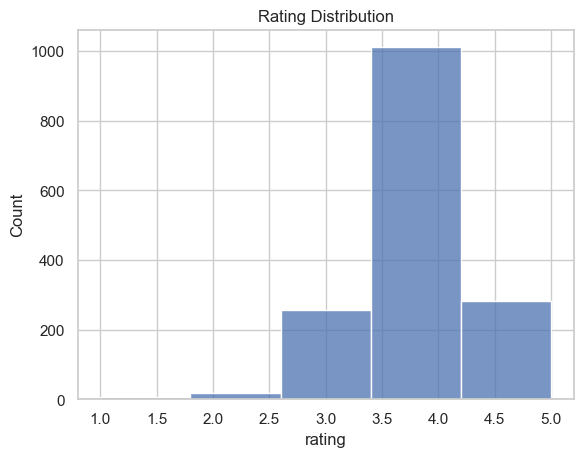

In [49]:
# Distribution of Ratings
sns.histplot(rating_data_clean['rating'], bins=5, kde=False)
plt.title("Rating Distribution")
plt.show()

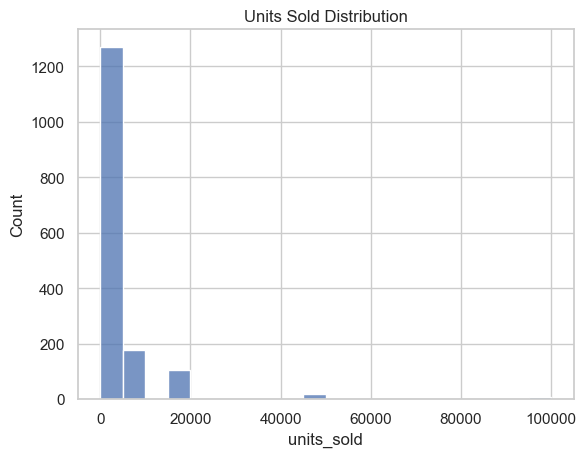

In [50]:
# Distribution of Sales
sns.histplot(rating_data_clean['units_sold'], bins=20, kde=False)
plt.title("Units Sold Distribution")
plt.show()


In [51]:
# Average sales by sentiment
avg_sales_sentiment = rating_data_clean.groupby('Sentiment_Label')['units_sold'].mean()
print(avg_sales_sentiment)

Sentiment_Label
Negative    3198.688427
Neutral     3922.869148
Positive    6152.722084
Name: units_sold, dtype: float64


/var/folders/cw/p6fgs1h909l5k4v0q_fw_6nw0000gn/T/ipykernel_1418/1759252841.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sales_sentiment = rating_data_clean.groupby('Sentiment_Label')['units_sold'].mean()


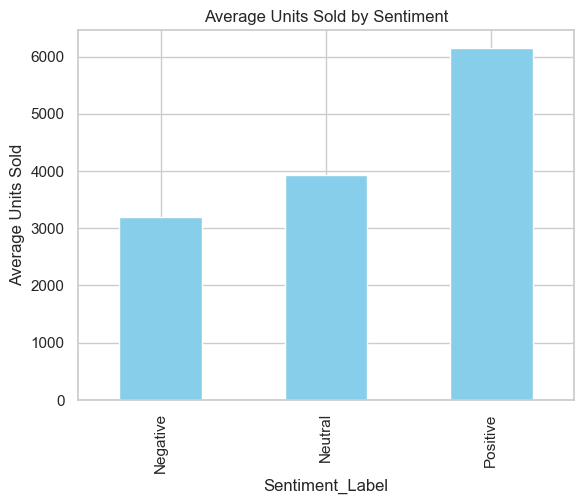

In [52]:
# Bar plot of average sales by sentiment
avg_sales_sentiment.plot(kind='bar', color='skyblue')
plt.ylabel("Average Units Sold")
plt.title("Average Units Sold by Sentiment")
plt.show()

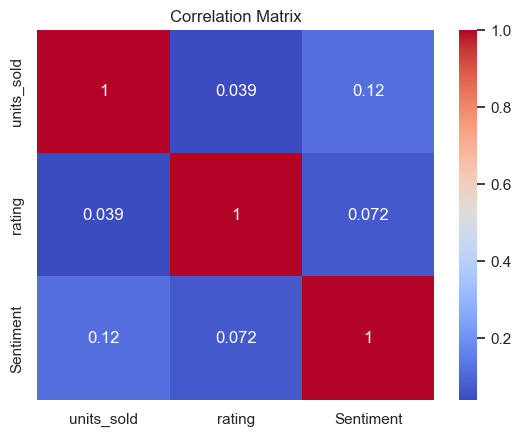

In [53]:
# Correlation matrix
corr = rating_data_clean[['units_sold','rating','Sentiment']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Hypothesis Testing

In [54]:
# Extracting positive and negative sentiment units_sold
sales_positive = rating_data_clean[rating_data_clean['Sentiment_Label']=='Positive']['units_sold']
sales_negative = rating_data_clean[rating_data_clean['Sentiment_Label']=='Negative']['units_sold']

In [57]:
# Two-sample t-test
t_stat, p_value = ttest_ind(sales_positive, sales_negative, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject H0: Positive sentiment affects sales.")
else:
    print("don’t reject H0: No significant difference.")

T-statistic: 3.905405487891833
P-value: 0.00010272343935878285
Reject H0: Positive sentiment affects sales.


# Causal Analysis with Regression

In [59]:
# Linear regression

import statsmodels.api as sm
import statsmodels.formula.api as smf

rating_data_clean['Sentiment_Score'] = rating_data_clean['Sentiment']  
model = smf.ols("units_sold ~ Sentiment_Score + rating", data=rating_data_clean).fit()
 
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     12.41
Date:                Sun, 21 Dec 2025   Prob (F-statistic):           4.48e-06
Time:                        13:30:05   Log-Likelihood:                -16602.
No. Observations:                1573   AIC:                         3.321e+04
Df Residuals:                    1570   BIC:                         3.323e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        2097.4892   1755.878     

Sentiment_Score coefficient shows expected change in units_sold per unit change in sentiment, controlling for rating.

p-value tells whether the effect is statistically significant.

# Visualization 

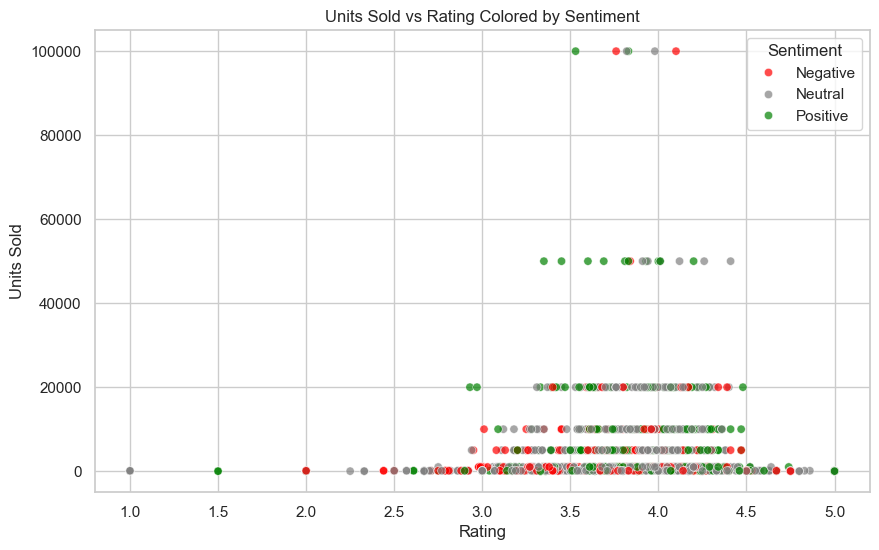

In [65]:
# Scatter plot: Sentiment vs Units Sold
plt.figure(figsize=(10,6))
sns.scatterplot(x='rating', y='units_sold', hue='Sentiment_Label', 
                palette={'Negative':'red', 'Neutral':'gray', 'Positive':'green'},
                data=rating_data_clean, alpha=0.7)
plt.title("Units Sold vs Rating Colored by Sentiment")
plt.xlabel("Rating")
plt.ylabel("Units Sold")
plt.legend(title="Sentiment")
plt.show()




The scatter plot shows the relationship between product rating and units sold, with points colored by sentiment category. Due to the discrete and often repeated values of units_sold and rating, many points align horizontally and vertically, creating “levels” rather than a smooth distribution. Despite this, a general pattern is visible: products with higher ratings and positive sentiment tend to have higher sales, while lower-rated or negatively labeled products cluster at lower sales. However, the plot also highlights that some products with neutral or negative sentiment can achieve high sales, suggesting that factors other than sentiment—like product popularity, price, or advertising—also play a role.

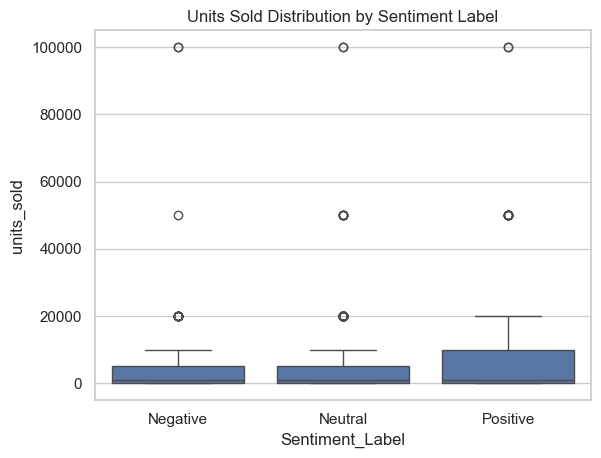

In [61]:
# Boxplot: Sentiment Label vs Units Sold
sns.boxplot(x='Sentiment_Label', y='units_sold', data=rating_data_clean)
plt.title("Units Sold Distribution by Sentiment Label")
plt.show()

The boxplot summarizes sales distributions for each sentiment category. It shows that products with positive sentiment generally have higher median units sold compared to neutral or negative sentiment products. The wide interquartile range and the presence of outliers reflect the skewed nature of sales, where a few products dominate total sales. While sentiment appears to be associated with higher average sales, the variability indicates that sentiment alone cannot fully explain sales outcomes. These visualizations, therefore, are useful for identifying trends and supporting exploratory insights but should be interpreted alongside other variables when considering causal effects.

# Conclusion

This analysis explored the relationship between product ratings, sentiment derived from product titles, and units sold. The results indicate that products with higher ratings and more positive sentiment tend to have higher sales on average, as seen in the scatter and box plots. However, there is considerable variability, and some products with neutral or negative sentiment still achieve strong sales, highlighting the influence of other factors such as price, category, and promotions. Overall, while positive sentiment appears to be beneficial, it should be considered alongside additional variables to make more confident decisions regarding sales strategies and marketing efforts.

# Next Steps

While this analysis suggests that positive sentiment and higher ratings are generally associated with increased sales, there is substantial variability, and other factors likely influence outcomes. Future steps could include incorporating additional variables such as product price, category, advertising boosts, or seasonal trends to better isolate the drivers of sales. Conducting a multivariate regression or causal inference analysis with these factors would provide a more robust understanding of what truly impacts units sold. Additionally, using full product reviews rather than just titles for sentiment analysis could strengthen the signal and improve insights.